# DLS Face Recognition — CE vs ArcFace: TPR/FPR, ROC and Identification Rate

**Remastered evaluation notebook — Fall 2025 training + Spring 2026 identity-disjoint test**

This notebook is intentionally **evaluation-only**: it does not train or tune either recognition model.

Its goals are:

1. reproduce the original DLS *Identification Rate* logic exactly;
2. compare frozen **Cross-Entropy** and **ArcFace** recognition backbones under one shared inference protocol;
3. calculate and visualize the full ROC relation `TPR(FPR)`;
4. report `TPR @ fixed FPR`, thresholds, ROC-AUC and EER;
5. keep the legacy same-ID and modern identity-disjoint interpretations separate.

> **Terminology note.** The DLS assignment calls this *Identification Rate*. Mathematically, `TPR@FPR` on genuine/impostor pairs is a **verification-style** metric. Classical identification (gallery/query Rank-1, CMC) is a separate protocol.

### Canonical routing used here

```text
Fall 2025
    train -> CE / ArcFace training (already completed)
    val   -> checkpoint selection (already completed)
    test  -> optional same-ID control

Spring 2026
    remove every identity occurring anywhere in Fall
    -> frozen Spring-only query + distractors
    -> final unseen-identity ROC / EER / TPR@FPR
```

The notebook defaults to the **Spring-only frozen final test**.


## 1. Imports

The notebook uses standard scientific Python packages plus PyTorch / torchvision / scikit-learn.
In Google Colab they are normally already installed.


In [1]:
from pathlib import Path
import json, math, platform, random, re, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, roc_auc_score

print("[environment]")
print("  Python      :", platform.python_version())
print("  PyTorch     :", torch.__version__)
print("  torchvision :", torchvision.__version__)


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


[environment]
  Python      : 3.13.5
  PyTorch     : 2.9.1
  torchvision : 0.24.1


## 2. Configuration — normally the only cell you edit

Set the four paths below:

- `FALL_ROOT` — Fall 2025 aligned dataset root containing `train/images`, `val/images`, `test/images`;
- `SPRING_ROOT` — Spring 2026 frontend root containing `final_21k_selection.csv` and `celeba_21k_aligned`;
- `CE_CKPT` — frozen Cross-Entropy `best.pt`;
- `ARCFACE_CKPT` — frozen ArcFace `best.pt`.

The notebook can build the Spring-only test directly from the manifest and Fall directory identities, so a precomputed `spring_images_absent_from_fall.csv` is **not required**.


In [2]:
# ============================================================
# EDIT THESE PATHS
# ============================================================

FALL_ROOT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2025.1.1осень/10_PROj/celeba_wild_aligned_112_splits_20")

SPRING_ROOT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1")
SPRING_MANIFEST = SPRING_ROOT / "final_21k_selection.csv"
SPRING_DATA_ROOT = SPRING_ROOT / "celeba_21k_aligned"

CE_CKPT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/B3/notebooks/4a-CE/best.CE.pt")
ARCFACE_CKPT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/B3/notebooks/4b-ArcFace/best.ArcFace.pt")

OUTPUT_DIR = SPRING_ROOT / "_final_evaluation/ce_vs_arcface_tpr_fpr_results"

SEED = 42
IMG_SIZE = 112
BATCH_SIZE = 128
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

EVALUATION_MODE = "spring_only_final"

STRICT_FROZEN_COUNTS = True
EXPECTED_QUERY_IDENTITIES = 235
EXPECTED_QUERY_IMAGES = 940
EXPECTED_DISTRACTOR_IDENTITIES = 1872
EXPECTED_DISTRACTOR_IMAGES = 1872

FPR_POINTS = [0.50, 0.20, 0.10, 0.05, 1e-2, 1e-3, 1e-4]
USE_EMBEDDING_CACHE = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "embeddings").mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = pick_device()

print("[config]")
print("  device       :", device)
print("  FALL_ROOT    :", FALL_ROOT)
print("  SPRING_ROOT  :", SPRING_ROOT)
print("  CE_CKPT      :", CE_CKPT)
print("  ARCFACE_CKPT :", ARCFACE_CKPT)
print("  OUTPUT_DIR   :", OUTPUT_DIR.resolve())


[config]
  device       : mps
  FALL_ROOT    : /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2025.1.1осень/10_PROj/celeba_wild_aligned_112_splits_20
  SPRING_ROOT  : /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1
  CE_CKPT      : /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/B3/notebooks/4a-CE/best.CE.pt
  ARCFACE_CKPT : /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/B3/notebooks/4b-ArcFace/best.ArcFace.pt
  OUTPUT_DIR   : /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_final_evaluation/ce_vs_arcface_tpr_fpr_results


## 3. Fail-fast path diagnostics

This cell intentionally runs **before** model loading or image inference.
If something is wrong, it reports exactly which artifact is missing.


In [3]:
required_paths = {
    "FALL_ROOT": FALL_ROOT,
    "Fall train/images": FALL_ROOT / "train" / "images",
    "Fall val/images": FALL_ROOT / "val" / "images",
    "Fall test/images": FALL_ROOT / "test" / "images",
    "SPRING_ROOT": SPRING_ROOT,
    "SPRING_MANIFEST": SPRING_MANIFEST,
    "SPRING_DATA_ROOT": SPRING_DATA_ROOT,
    "Spring query": SPRING_DATA_ROOT / "test" / "query",
    "Spring distractors": SPRING_DATA_ROOT / "test" / "distractors",
    "CE_CKPT": CE_CKPT,
    "ARCFACE_CKPT": ARCFACE_CKPT,
}

missing = [(name, path) for name, path in required_paths.items() if not path.exists()]

if missing:
    msg = "\n".join(f"  - {name}: {path}" for name, path in missing)
    raise FileNotFoundError(
        "Required project paths are missing.\n"
        "Edit Cell 2 and rerun.\n\n"
        f"{msg}"
    )

print("[OK] all required roots/checkpoints exist")


[OK] all required roots/checkpoints exist


## 4. Build the Spring-only identity-disjoint evaluation pool

- **Fall identity:** parent directory name.
- **Spring identity:** `final_21k_selection.csv["identity_id"]`.

Every Spring identity occurring anywhere in Fall is removed before final evaluation.

Expected frozen result:

```text
query       = 235 identities × 4 images = 940 images
distractors = 1,872 identities × 1 image = 1,872 images
```


In [4]:
def norm_identity(x):
    s = str(x).strip()
    if re.fullmatch(r"[+-]?\d+\.0", s):
        s = s[:-2]
    return s

def fall_identity_set(root):
    ids = set()
    for split in ["train", "val", "test"]:
        base = root / split / "images"
        ids.update(norm_identity(p.name) for p in base.iterdir() if p.is_dir())
    return ids

fall_ids = fall_identity_set(FALL_ROOT)
assert fall_ids, "No Fall identity directories were found."

spring = pd.read_csv(
    SPRING_MANIFEST,
    dtype={"filename": str, "identity_id": str, "final_subset": str, "aligned_path": str},
)

required_cols = {"filename", "identity_id", "final_subset"}
missing_cols = required_cols - set(spring.columns)
assert not missing_cols, f"Spring manifest missing columns: {sorted(missing_cols)}"

spring["identity_id"] = spring["identity_id"].map(norm_identity)

def canonical_subset(x):
    x = str(x).strip().lower().replace("-", "_").replace("/", "_")
    aliases = {
        "train": "train",
        "validation": "validation",
        "val": "validation",
        "query": "test_query",
        "test_query": "test_query",
        "distractor": "test_distractor",
        "distractors": "test_distractor",
        "test_distractor": "test_distractor",
        "test_distractors": "test_distractor",
    }
    if x not in aliases:
        raise ValueError(f"Unknown final_subset value: {x!r}")
    return aliases[x]

spring["subset"] = spring["final_subset"].map(canonical_subset)

def canonical_spring_path(row):
    fn = str(row["filename"])
    subset = row["subset"]
    if subset == "train":
        return SPRING_DATA_ROOT / "train" / fn
    if subset == "validation":
        return SPRING_DATA_ROOT / "validation" / fn
    if subset == "test_query":
        return SPRING_DATA_ROOT / "test" / "query" / fn
    if subset == "test_distractor":
        return SPRING_DATA_ROOT / "test" / "distractors" / fn
    raise ValueError(subset)

def resolve_spring_path(row):
    if "aligned_path" in row.index and pd.notna(row["aligned_path"]):
        p = Path(str(row["aligned_path"])).expanduser()
        if p.exists():
            return p
    return canonical_spring_path(row)

spring["resolved_path"] = spring.apply(resolve_spring_path, axis=1)

spring_test = spring[spring["subset"].isin(["test_query", "test_distractor"])].copy()
spring_test["seen_in_fall"] = spring_test["identity_id"].isin(fall_ids)

query_df = (
    spring_test[(spring_test["subset"] == "test_query") & (~spring_test["seen_in_fall"])]
    .sort_values(["identity_id", "filename"])
    .reset_index(drop=True)
)

distractor_df = (
    spring_test[(spring_test["subset"] == "test_distractor") & (~spring_test["seen_in_fall"])]
    .sort_values(["identity_id", "filename"])
    .reset_index(drop=True)
)

query_ids = set(query_df["identity_id"])
distractor_ids = set(distractor_df["identity_id"])

assert fall_ids.isdisjoint(query_ids), "Leakage: Fall identity appears in filtered query."
assert fall_ids.isdisjoint(distractor_ids), "Leakage: Fall identity appears in filtered distractors."
assert query_ids.isdisjoint(distractor_ids), "Leakage: query and distractor identities overlap."

all_eval = pd.concat([query_df, distractor_df], ignore_index=True)
missing_images = all_eval[~all_eval["resolved_path"].map(Path.exists)]
assert len(missing_images) == 0, (
    f"{len(missing_images)} evaluation images are missing.\n"
    + missing_images[["subset", "filename", "resolved_path"]].head(20).to_string(index=False)
)

query_counts = query_df.groupby("identity_id").size()
distractor_counts = distractor_df.groupby("identity_id").size()

print("[cross-dataset audit]")
print("  Fall identities                     :", len(fall_ids))
print("  Spring test IDs seen in Fall        :", spring_test.loc[spring_test["seen_in_fall"], "identity_id"].nunique())
print("  filtered query identities           :", len(query_counts))
print("  filtered query images               :", len(query_df))
print("  filtered distractor identities      :", len(distractor_counts))
print("  filtered distractor images          :", len(distractor_df))

if STRICT_FROZEN_COUNTS:
    assert len(query_counts) == EXPECTED_QUERY_IDENTITIES
    assert len(query_df) == EXPECTED_QUERY_IMAGES
    assert (query_counts == 4).all()
    assert len(distractor_counts) == EXPECTED_DISTRACTOR_IDENTITIES
    assert len(distractor_df) == EXPECTED_DISTRACTOR_IMAGES
    assert (distractor_counts == 1).all()

print("[OK] Spring-only frozen test contract passed")


[cross-dataset audit]
  Fall identities                     : 666
  Spring test IDs seen in Fall        : 143
  filtered query identities           : 235
  filtered query images               : 940
  filtered distractor identities      : 1872
  filtered distractor images          : 1872
[OK] Spring-only frozen test contract passed


## 5. Pair-count sanity check and statistical resolution

The number of impostor pairs determines how finely low FPR can be resolved.


In [5]:
n_query = len(query_df)
n_distr = len(distractor_df)

n_pos = int(sum(math.comb(int(n), 2) for n in query_counts))
n_query_total_pairs = math.comb(n_query, 2)
n_query_neg = n_query_total_pairs - n_pos
n_qd = n_query * n_distr
n_neg = n_query_neg + n_qd

print("[pair population]")
print(f"  genuine query-query          : {n_pos:,}")
print(f"  query-query impostor         : {n_query_neg:,}")
print(f"  query-distractor impostor    : {n_qd:,}")
print(f"  total impostor               : {n_neg:,}")
print(f"  minimum empirical FPR step   : {1/n_neg:.3e}")

resolution_df = pd.DataFrame([
    {
        "target_fpr": fpr,
        "expected_false_accepts": fpr * n_neg,
        "approx_binomial_se": math.sqrt(max(fpr * (1-fpr) / n_neg, 0)),
    }
    for fpr in FPR_POINTS
])
display(resolution_df)


[pair population]
  genuine query-query          : 1,410
  query-query impostor         : 439,920
  query-distractor impostor    : 1,759,680
  total impostor               : 2,199,600
  minimum empirical FPR step   : 4.546e-07


,target_fpr,expected_false_accepts,approx_binomial_se
0,0.5000,1099800.00,0.000337
1,0.2000,439920.00,0.000270
2,0.1000,219960.00,0.000202
3,0.0500,109980.00,0.000147
4,0.0100,21996.00,0.000067
5,0.0010,2199.60,0.000021
6,0.0001,219.96,0.000007


## 6. Shared deterministic inference preprocessing

```text
aligned RGB face
-> Resize(112,112)
-> ToTensor
-> Normalize(mean=[0.5]*3, std=[0.5]*3)
-> backbone
-> L2 normalization
```


In [6]:
inference_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class ManifestFaceDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        path = Path(row["resolved_path"])
        with Image.open(path) as im:
            image = im.convert("RGB")
        x = self.transform(image)
        return x, str(row["identity_id"]), str(row["filename"])

query_ds = ManifestFaceDataset(query_df, inference_transform)
distractor_ds = ManifestFaceDataset(distractor_df, inference_transform)

query_loader = DataLoader(
    query_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
distractor_loader = DataLoader(
    distractor_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

xb, ids_b, names_b = next(iter(query_loader))
assert xb.shape[1:] == (3, IMG_SIZE, IMG_SIZE)
print("[sanity] batch shape:", tuple(xb.shape))
print("[sanity] sample IDs :", list(ids_b[:5]))


[sanity] batch shape: (128, 3, 112, 112)
[sanity] sample IDs : ['10003', '10003', '10003', '10003', '10067']


## 7. Recognition models and strict checkpoint loading

CE expects `best.pt["model_state"]`; ArcFace expects `best.pt["backbone_state"]`.

No `strict=False` is used. Historical namespace variants are accepted only if a **strict** load succeeds.


In [7]:
def safe_torch_load(path, map_location="cpu"):
    path = Path(path)
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def make_resnet(backbone_name):
    name = str(backbone_name).lower()
    if name == "resnet18":
        net = torchvision.models.resnet18(weights=None)
    elif name == "resnet34":
        net = torchvision.models.resnet34(weights=None)
    elif name == "resnet50":
        net = torchvision.models.resnet50(weights=None)
    else:
        raise ValueError(f"Unsupported backbone: {backbone_name}")
    embedding_dim = int(net.fc.in_features)
    net.fc = nn.Identity()
    return net, embedding_dim

class CEResNet(nn.Module):
    def __init__(self, backbone_name, num_classes):
        super().__init__()
        self.backbone_name = str(backbone_name).lower()
        self.backbone, self.embedding_dim = make_resnet(self.backbone_name)
        self.classifier = nn.Linear(self.embedding_dim, int(num_classes))

    def forward_features(self, x):
        return self.backbone(x)

    def forward(self, x):
        return self.classifier(self.forward_features(x))

class CEEmbeddingModel(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.full_model = full_model
        self.embedding_dim = full_model.embedding_dim

    def forward(self, x):
        return self.full_model.forward_features(x)

class RecognitionBackbone(nn.Module):
    def __init__(self, backbone_name):
        super().__init__()
        self.backbone_name = str(backbone_name).lower()
        self.backbone, self.embedding_dim = make_resnet(self.backbone_name)

    def forward(self, x):
        return self.backbone(x)

def infer_num_classes_from_state(state):
    for key in ["classifier.weight", "module.classifier.weight"]:
        if key in state:
            return int(state[key].shape[0])
    raise KeyError("Could not infer CE num_classes from checkpoint.")

def strict_load_known_namespaces(module, state, label):
    candidates = [("as-is", state)]

    if any(k.startswith("module.") for k in state):
        candidates.append(("strip module.", {k.replace("module.", "", 1): v for k, v in state.items()}))

    if not any(k.startswith("backbone.") for k in state):
        candidates.append(("add backbone.", {"backbone." + k: v for k, v in state.items()}))

    if state and all(k.startswith("backbone.") for k in state):
        candidates.append(("strip backbone.", {k[len("backbone."):]: v for k, v in state.items()}))

    errors = []
    for name, candidate in candidates:
        try:
            module.load_state_dict(candidate, strict=True)
            print(f"[OK] {label}: strict checkpoint load ({name})")
            return name
        except RuntimeError as e:
            errors.append((name, str(e).splitlines()[0]))

    details = "\n".join(f"  - {name}: {err}" for name, err in errors)
    raise RuntimeError(
        f"Could not strictly load {label} checkpoint using known namespace variants.\n"
        f"{details}\n"
        "Provide the corresponding training notebook if this checkpoint uses another contract."
    )

ce_payload = safe_torch_load(CE_CKPT)
arc_payload = safe_torch_load(ARCFACE_CKPT)

assert isinstance(ce_payload, dict) and "model_state" in ce_payload
assert isinstance(arc_payload, dict) and "backbone_state" in arc_payload

ce_backbone_name = str(ce_payload.get("backbone", "resnet18"))
arc_backbone_name = str(arc_payload.get("backbone", "resnet18"))

ce_state = ce_payload["model_state"]
arc_state = arc_payload["backbone_state"]

ce_num_classes = int(ce_payload.get("num_classes", infer_num_classes_from_state(ce_state)))

ce_full = CEResNet(ce_backbone_name, ce_num_classes)
strict_load_known_namespaces(ce_full, ce_state, "Cross-Entropy")
ce_model = CEEmbeddingModel(ce_full).to(device).eval()

arc_model = RecognitionBackbone(arc_backbone_name)
strict_load_known_namespaces(arc_model, arc_state, "ArcFace")
arc_model = arc_model.to(device).eval()

assert ce_model.embedding_dim == arc_model.embedding_dim

print("[model contract]")
print("  CE backbone      :", ce_backbone_name)
print("  ArcFace backbone :", arc_backbone_name)
print("  embedding dim    :", ce_model.embedding_dim)
print("  CE classes       :", ce_num_classes)


[OK] Cross-Entropy: strict checkpoint load (as-is)
[OK] ArcFace: strict checkpoint load (as-is)
[model contract]
  CE backbone      : resnet18
  ArcFace backbone : resnet18
  embedding dim    : 512
  CE classes       : 666


## 8. Extract and cache normalized embeddings

Both outputs are explicitly L2-normalized here.


In [8]:
@torch.inference_mode()
def compute_embeddings(model, loader, device):
    all_emb, all_ids, all_names = [], [], []

    for x, ids, names in loader:
        x = x.to(device, non_blocking=True)
        z = F.normalize(model(x), p=2, dim=1)
        all_emb.append(z.detach().cpu().numpy().astype(np.float32))
        all_ids.extend(map(str, ids))
        all_names.extend(map(str, names))

    emb = np.concatenate(all_emb, axis=0)
    norms = np.linalg.norm(emb, axis=1)
    assert np.isfinite(emb).all()
    assert np.allclose(norms, 1.0, atol=1e-4)
    return emb, np.asarray(all_ids, dtype=str), np.asarray(all_names, dtype=str)

def cache_path(model_name, split_name):
    return OUTPUT_DIR / "embeddings" / f"{model_name}_{split_name}_spring_only.npz"

def get_or_compute(model_name, model, split_name, loader):
    path = cache_path(model_name, split_name)

    if USE_EMBEDDING_CACHE and path.exists():
        d = np.load(path, allow_pickle=False)
        print(f"[cache] loaded {path}")
        return d["embeddings"], d["identity_ids"].astype(str), d["filenames"].astype(str)

    emb, ids, names = compute_embeddings(model, loader, device)
    np.savez_compressed(path, embeddings=emb, identity_ids=ids, filenames=names)
    print(f"[cache] saved {path}")
    return emb, ids, names

ce_q, q_ids_ce, q_names_ce = get_or_compute("ce", ce_model, "query", query_loader)
ce_d, d_ids_ce, d_names_ce = get_or_compute("ce", ce_model, "distractors", distractor_loader)

arc_q, q_ids_arc, q_names_arc = get_or_compute("arcface", arc_model, "query", query_loader)
arc_d, d_ids_arc, d_names_arc = get_or_compute("arcface", arc_model, "distractors", distractor_loader)

assert np.array_equal(q_ids_ce, q_ids_arc)
assert np.array_equal(d_ids_ce, d_ids_arc)
assert np.array_equal(q_names_ce, q_names_arc)
assert np.array_equal(d_names_ce, d_names_arc)

print("[OK] both models evaluated on exactly the same ordered images")
print("  query      :", ce_q.shape)
print("  distractor :", ce_d.shape)


[cache] saved /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_final_evaluation/ce_vs_arcface_tpr_fpr_results/embeddings/ce_query_spring_only.npz
[cache] saved /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_final_evaluation/ce_vs_arcface_tpr_fpr_results/embeddings/ce_distractors_spring_only.npz
[cache] saved /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_final_evaluation/ce_vs_arcface_tpr_fpr_results/embeddings/arcface_query_spring_only.npz
[cache] saved /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_final_evaluation/ce_vs_arcface_tpr_fpr_results/embeddings/arcface_distra

## 9. Original DLS Identification Rate implementation and tests

This section preserves the school logic exactly.


In [9]:
def cosine_similarity(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def compute_cosine_query_pos(query_dict, query_img_names, query_embeddings):
    name_to_idx = {name: i for i, name in enumerate(query_img_names)}
    out = []
    for names in query_dict.values():
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                out.append(cosine_similarity(
                    query_embeddings[name_to_idx[names[i]]],
                    query_embeddings[name_to_idx[names[j]]]
                ))
    return out

def compute_cosine_query_neg(query_dict, query_img_names, query_embeddings):
    name_to_class = {}
    for cls, names in query_dict.items():
        for name in names:
            name_to_class[name] = cls

    out = []
    for i in range(len(query_img_names)):
        for j in range(i + 1, len(query_img_names)):
            if name_to_class[query_img_names[i]] != name_to_class[query_img_names[j]]:
                out.append(cosine_similarity(query_embeddings[i], query_embeddings[j]))
    return out

def compute_cosine_query_distractors(query_embeddings, distractors_embeddings):
    out = []
    for q in query_embeddings:
        for d in distractors_embeddings:
            out.append(cosine_similarity(q, d))
    return out

def compute_ir(cosine_query_pos, cosine_query_neg, cosine_query_distractors, fpr=0.1):
    if not (0 < fpr <= 1):
        raise ValueError("fpr must be in (0, 1].")

    pos = np.asarray(cosine_query_pos, dtype=np.float64)
    neg = np.concatenate([
        np.asarray(cosine_query_neg, dtype=np.float64),
        np.asarray(cosine_query_distractors, dtype=np.float64),
    ])

    rank = max(1, int(math.ceil(fpr * len(neg))))
    threshold = np.partition(neg, len(neg) - rank)[len(neg) - rank]
    tpr = float(np.mean(pos >= threshold))
    return float(threshold), tpr

test_query_dict = {
    2876: ['1.jpg', '2.jpg', '3.jpg'],
    5674: ['5.jpg'],
    864:  ['9.jpg', '10.jpg'],
}
test_query_img_names = ['1.jpg', '2.jpg', '3.jpg', '5.jpg', '9.jpg', '10.jpg']
test_query_embeddings = [
    [1.56, 6.45, -7.68], [-1.1, 6.11, -3.0], [-0.06, -0.98, -1.29],
    [8.56, 1.45, 1.11], [0.7, 1.1, -7.56], [0.05, 0.9, -2.56],
]
test_distractors_embeddings = [
    [0.12, -3.23, -5.55], [-1, -0.01, 1.22], [0.06, -0.23, 1.34],
    [-6.6, 1.45, -1.45], [0.89, 1.98, 1.45],
]

test_pos = compute_cosine_query_pos(test_query_dict, test_query_img_names, test_query_embeddings)
test_neg = compute_cosine_query_neg(test_query_dict, test_query_img_names, test_query_embeddings)
test_qd = compute_cosine_query_distractors(test_query_embeddings, test_distractors_embeddings)

true_pos = [0.8678237233650096, 0.21226104378511604, -0.18355866977496182, 0.9787437979250561]
true_neg = [0.15963231223161822, 0.8507997093616965, 0.9272761484302097,
            -0.0643994061127092, 0.5412660901220571, 0.701307100338029,
            -0.2372575528216902, 0.6941032794522218, 0.549425446066643,
            -0.011982733001947084, -0.0466679194884999]
true_qd = [0.3371426578637511, -0.6866465610863652, -0.8456563512871669,
           0.14530087113136106, 0.11410510307646118, -0.07265097629002357,
           -0.24097699660707042, -0.5851992679925766, 0.4295494455718534,
           0.37604478596058194, 0.9909483738948858, -0.5881093317868022,
           -0.6829712976642919, 0.07546364489032083, -0.9130970963915521,
           -0.17463101988684684, -0.5229363015558941, 0.1399896725311533,
           -0.9258034013399499, 0.5295114163723346, 0.7811585442749943,
           -0.8208760031249596, -0.9905139680301821, 0.14969764653247228,
           -0.40749654525418444, 0.648660814944824, -0.7432584300096284,
           -0.9839696492435877, 0.2498741082804709, -0.2661183373780491]

assert np.allclose(sorted(test_pos), sorted(true_pos))
assert np.allclose(sorted(test_neg), sorted(true_neg))
assert np.allclose(sorted(test_qd), sorted(true_qd))

test_thr, test_tpr = [], []
for fpr in [0.5, 0.3, 0.1]:
    thr, tpr = compute_ir(test_pos, test_neg, test_qd, fpr)
    test_thr.append(thr)
    test_tpr.append(tpr)

assert np.allclose(test_thr, [-0.011982733001947084, 0.3371426578637511, 0.701307100338029])
assert np.allclose(test_tpr, [0.75, 0.5, 0.5])

print("[OK] all original DLS reference tests passed")


[OK] all original DLS reference tests passed


## 10. Fast vectorized score construction for the real dataset

The same pair definitions are evaluated efficiently for millions of pairs.


In [10]:
def build_scores(query_emb, query_ids, distractor_emb):
    query_emb = np.asarray(query_emb, dtype=np.float32)
    distractor_emb = np.asarray(distractor_emb, dtype=np.float32)
    query_ids = np.asarray(query_ids, dtype=str)

    qq = query_emb @ query_emb.T
    iu = np.triu_indices(len(query_emb), k=1)

    qq_scores = qq[iu]
    same = query_ids[iu[0]] == query_ids[iu[1]]

    genuine = qq_scores[same].astype(np.float32, copy=False)
    query_impostor = qq_scores[~same].astype(np.float32, copy=False)
    qd = (query_emb @ distractor_emb.T).reshape(-1).astype(np.float32, copy=False)
    impostor = np.concatenate([query_impostor, qd])

    return {
        "genuine": genuine,
        "query_impostor": query_impostor,
        "query_distractor": qd,
        "impostor": impostor,
    }

scores = {
    "CE": build_scores(ce_q, q_ids_ce, ce_d),
    "ArcFace": build_scores(arc_q, q_ids_arc, arc_d),
}

for model_name, s in scores.items():
    assert len(s["genuine"]) == n_pos
    assert len(s["query_impostor"]) == n_query_neg
    assert len(s["query_distractor"]) == n_qd
    assert len(s["impostor"]) == n_neg
    assert np.isfinite(s["genuine"]).all()
    assert np.isfinite(s["impostor"]).all()
    print(f"[{model_name}] genuine={len(s['genuine']):,}, impostor={len(s['impostor']):,}")

print("[OK] pair counts match the frozen protocol")


[CE] genuine=1,410, impostor=2,199,600
[ArcFace] genuine=1,410, impostor=2,199,600
[OK] pair counts match the frozen protocol


## 11. TPR @ fixed FPR — direct CE vs ArcFace comparison

At the same FPR, higher TPR is better.


In [11]:
def dls_operating_point(genuine, impostor, fpr):
    rank = max(1, int(math.ceil(float(fpr) * len(impostor))))
    threshold = np.partition(impostor, len(impostor) - rank)[len(impostor) - rank]
    tpr = float(np.mean(genuine >= threshold))
    actual_fpr = float(np.mean(impostor >= threshold))
    return float(threshold), tpr, actual_fpr, rank

op_rows = []

for fpr in FPR_POINTS:
    row = {"FPR_target": float(fpr)}
    for model_name in ["CE", "ArcFace"]:
        s = scores[model_name]
        thr, tpr, actual_fpr, rank = dls_operating_point(s["genuine"], s["impostor"], fpr)
        row[f"{model_name}_threshold"] = thr
        row[f"{model_name}_TPR"] = tpr
        row[f"{model_name}_FPR_actual"] = actual_fpr
        row[f"{model_name}_FRR"] = 1.0 - tpr
        row[f"{model_name}_false_accept_rank"] = rank
    row["CE_minus_ArcFace_TPR"] = row["CE_TPR"] - row["ArcFace_TPR"]
    op_rows.append(row)

operating_points = pd.DataFrame(op_rows)
operating_points.to_csv(OUTPUT_DIR / "operating_points.csv", index=False)

display(
    operating_points[
        ["FPR_target", "CE_TPR", "ArcFace_TPR", "CE_minus_ArcFace_TPR",
         "CE_threshold", "ArcFace_threshold"]
    ].style.format({
        "FPR_target": "{:.4g}",
        "CE_TPR": "{:.4f}",
        "ArcFace_TPR": "{:.4f}",
        "CE_minus_ArcFace_TPR": "{:+.4f}",
        "CE_threshold": "{:.4f}",
        "ArcFace_threshold": "{:.4f}",
    })
)


,FPR_target,CE_TPR,ArcFace_TPR,CE_minus_ArcFace_TPR,CE_threshold,ArcFace_threshold
0,0.5,0.9844,0.9752,+0.0092,0.3993,0.4890
1,0.2,0.9291,0.9021,+0.0270,0.4752,0.5543
2,0.1,0.8674,0.7887,+0.0787,0.5223,0.5921
3,0.05,0.7972,0.6823,+0.1149,0.5648,0.6248
4,0.01,0.5894,0.4383,+0.1511,0.6496,0.6878
5,0.001,0.2993,0.1929,+0.1064,0.7435,0.7572
6,0.0001,0.1277,0.0716,+0.0560,0.8126,0.8108


## 12. Full ROC curves, ROC-AUC and EER

Both global ROC and low-FPR logarithmic ROC are shown.


,model,roc_auc,eer,eer_threshold,genuine_mean,genuine_std,impostor_mean,impostor_std,mean_separation
0,CE,0.952670,0.116379,0.512407,0.671413,0.122438,0.409607,0.084142,0.261806
1,ArcFace,0.930289,0.145390,0.572473,0.672414,0.092956,0.495850,0.071674,0.176564


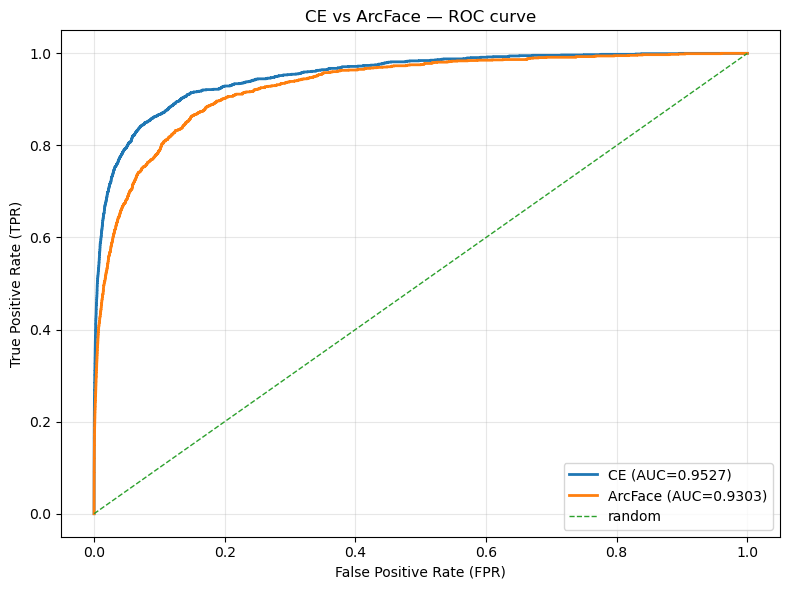

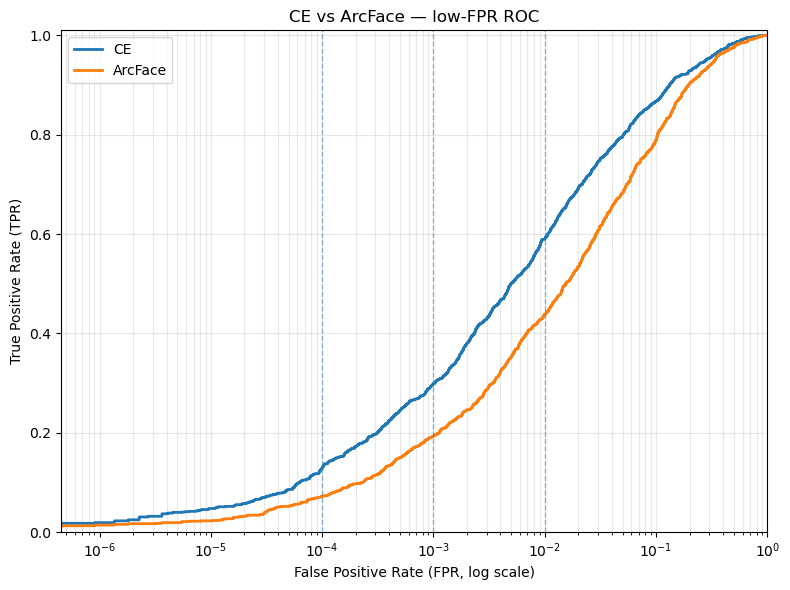

In [12]:
roc_data = {}
summary_rows = []

def compute_eer(fpr, tpr, thresholds):
    fnr = 1.0 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    eer = float((fpr[idx] + fnr[idx]) / 2.0)
    return eer, float(thresholds[idx])

for model_name in ["CE", "ArcFace"]:
    genuine = scores[model_name]["genuine"].astype(np.float64)
    impostor = scores[model_name]["impostor"].astype(np.float64)

    y_true = np.concatenate([
        np.ones(len(genuine), dtype=np.uint8),
        np.zeros(len(impostor), dtype=np.uint8),
    ])
    y_score = np.concatenate([genuine, impostor])

    fpr, tpr, thresholds = roc_curve(y_true, y_score, drop_intermediate=True)
    auc = float(roc_auc_score(y_true, y_score))
    eer, eer_thr = compute_eer(fpr, tpr, thresholds)

    roc_data[model_name] = {
        "fpr": fpr, "tpr": tpr, "thresholds": thresholds,
        "auc": auc, "eer": eer, "eer_threshold": eer_thr,
    }

    summary_rows.append({
        "model": model_name,
        "roc_auc": auc,
        "eer": eer,
        "eer_threshold": eer_thr,
        "genuine_mean": float(genuine.mean()),
        "genuine_std": float(genuine.std()),
        "impostor_mean": float(impostor.mean()),
        "impostor_std": float(impostor.std()),
        "mean_separation": float(genuine.mean() - impostor.mean()),
    })

verification_summary = pd.DataFrame(summary_rows)
verification_summary.to_csv(OUTPUT_DIR / "verification_summary.csv", index=False)
display(verification_summary)

fig, ax = plt.subplots(figsize=(8, 6))
for model_name in ["CE", "ArcFace"]:
    d = roc_data[model_name]
    ax.plot(d["fpr"], d["tpr"], linewidth=2, label=f"{model_name} (AUC={d['auc']:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="random")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("CE vs ArcFace — ROC curve")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "roc_linear.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for model_name in ["CE", "ArcFace"]:
    d = roc_data[model_name]
    mask = d["fpr"] > 0
    ax.semilogx(d["fpr"][mask], d["tpr"][mask], linewidth=2, label=model_name)

for fpr_target in [1e-2, 1e-3, 1e-4]:
    ax.axvline(fpr_target, linestyle="--", linewidth=1, alpha=0.5)

ax.set_xlim(max(1/n_neg, 1e-7), 1)
ax.set_ylim(0, 1.01)
ax.set_xlabel("False Positive Rate (FPR, log scale)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("CE vs ArcFace — low-FPR ROC")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "roc_log_fpr.png", dpi=180)
plt.show()


## 13. TPR as a function of selected FPR


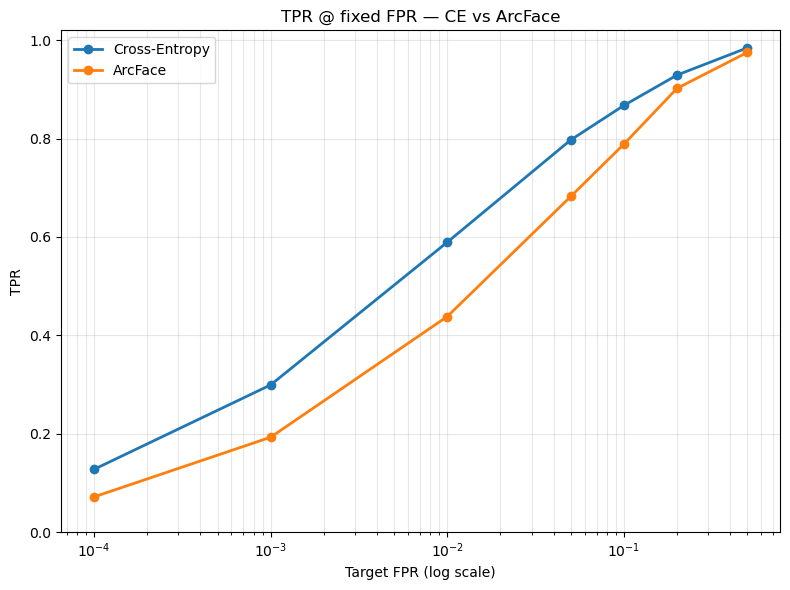

In [13]:
plot_df = operating_points.sort_values("FPR_target")

fig, ax = plt.subplots(figsize=(8, 6))
ax.semilogx(plot_df["FPR_target"], plot_df["CE_TPR"], marker="o", linewidth=2, label="Cross-Entropy")
ax.semilogx(plot_df["FPR_target"], plot_df["ArcFace_TPR"], marker="o", linewidth=2, label="ArcFace")
ax.set_xlabel("Target FPR (log scale)")
ax.set_ylabel("TPR")
ax.set_title("TPR @ fixed FPR — CE vs ArcFace")
ax.set_ylim(0, 1.02)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "tpr_at_fpr.png", dpi=180)
plt.show()


## 14. Genuine and impostor score distributions

Threshold values are model-specific. Compare systems at matched FPR, not by raw cosine threshold magnitude.


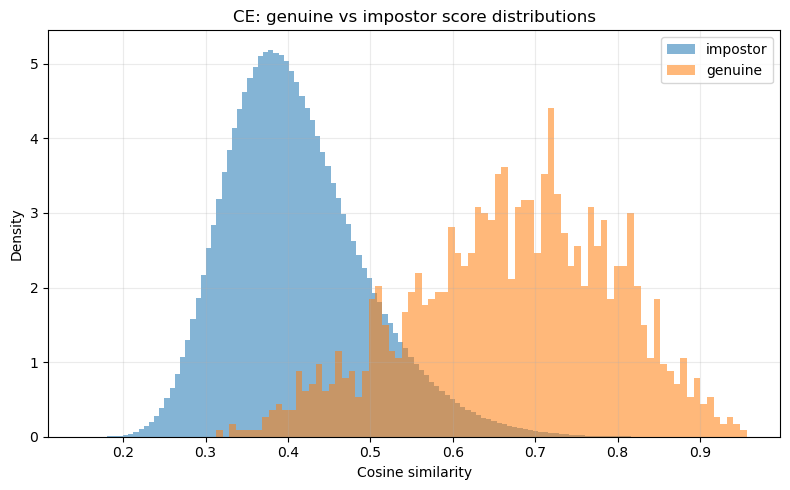

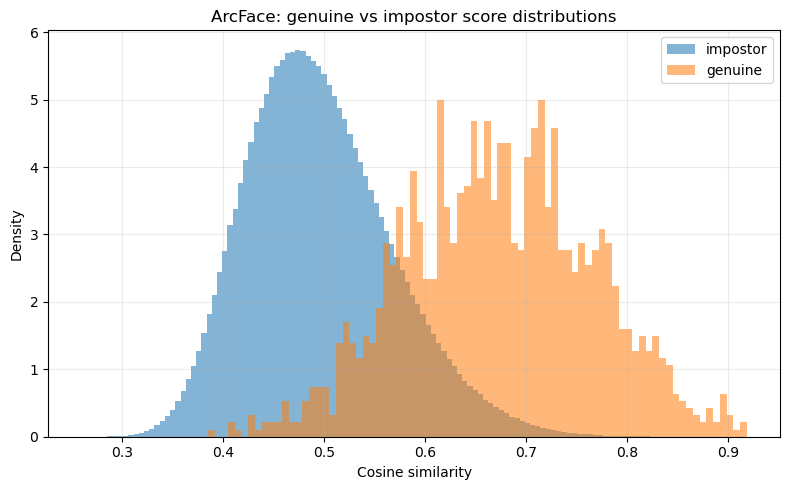

,model,population,n,mean,median,std,min,max,p99,p999
0,CE,genuine,1410,0.671413,0.680963,0.122438,0.312650,0.956826,0.912809,0.946869
1,CE,query_impostor,439920,0.410038,0.399632,0.083892,0.160001,0.895952,0.649441,0.740833
2,CE,query_distractor,1759680,0.409499,0.399191,0.084203,0.149212,0.905136,0.649661,0.743989
3,CE,impostor,2199600,0.409607,0.399282,0.084142,0.149212,0.905136,0.649610,0.743509
4,ArcFace,genuine,1410,0.672414,0.672183,0.092956,0.385070,0.918373,0.883183,0.913748
5,ArcFace,query_impostor,439920,0.495207,0.488357,0.071560,0.260381,0.857598,0.687463,0.759527
6,ArcFace,query_distractor,1759680,0.496011,0.489200,0.071701,0.260037,0.879398,0.687894,0.756667
7,ArcFace,impostor,2199600,0.495850,0.489024,0.071674,0.260037,0.879398,0.687799,0.757234


In [14]:
for model_name in ["CE", "ArcFace"]:
    s = scores[model_name]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(s["impostor"], bins=120, density=True, alpha=0.55, label="impostor")
    ax.hist(s["genuine"], bins=80, density=True, alpha=0.55, label="genuine")
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Density")
    ax.set_title(f"{model_name}: genuine vs impostor score distributions")
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "figures" / f"{model_name.lower()}_score_distributions.png", dpi=180)
    plt.show()

distribution_rows = []
for model_name in ["CE", "ArcFace"]:
    s = scores[model_name]
    for population in ["genuine", "query_impostor", "query_distractor", "impostor"]:
        x = s[population].astype(np.float64)
        distribution_rows.append({
            "model": model_name,
            "population": population,
            "n": len(x),
            "mean": x.mean(),
            "median": np.median(x),
            "std": x.std(),
            "min": x.min(),
            "max": x.max(),
            "p99": np.quantile(x, 0.99),
            "p999": np.quantile(x, 0.999),
        })

distribution_summary = pd.DataFrame(distribution_rows)
distribution_summary.to_csv(OUTPUT_DIR / "score_distribution_summary.csv", index=False)
display(distribution_summary)


## 15. Compact fixed-FPR comparison chart


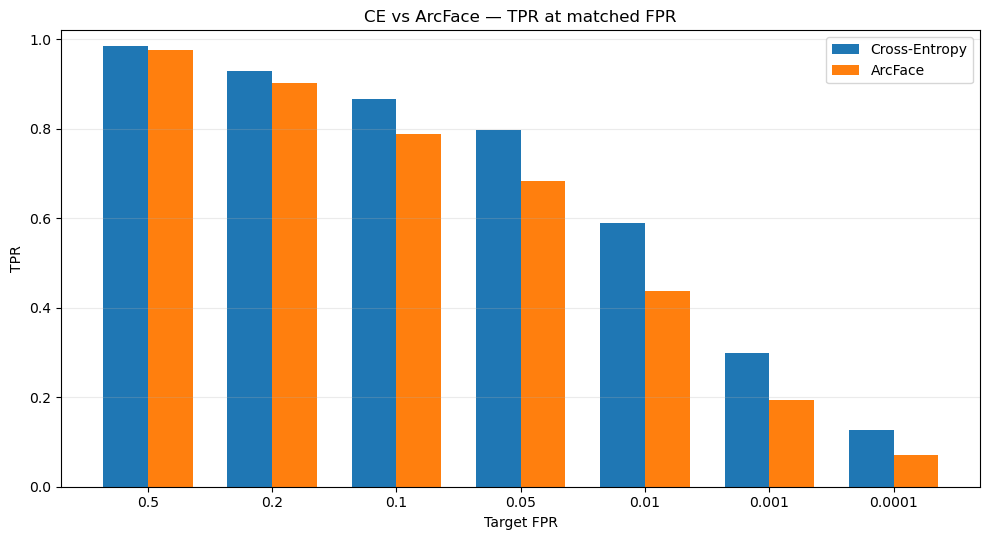

In [15]:
bar_df = operating_points.copy()
labels = [f"{x:g}" for x in bar_df["FPR_target"]]
x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - width/2, bar_df["CE_TPR"], width, label="Cross-Entropy")
ax.bar(x + width/2, bar_df["ArcFace_TPR"], width, label="ArcFace")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Target FPR")
ax.set_ylabel("TPR")
ax.set_title("CE vs ArcFace — TPR at matched FPR")
ax.set_ylim(0, 1.02)
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "tpr_operating_points_bar.png", dpi=180)
plt.show()


## 16. Automatic interpretation and machine-readable export

The conclusion is restricted to these frozen checkpoints and this frozen protocol.


In [16]:
ce_auc = float(verification_summary.loc[verification_summary["model"] == "CE", "roc_auc"].iloc[0])
arc_auc = float(verification_summary.loc[verification_summary["model"] == "ArcFace", "roc_auc"].iloc[0])

wins = int((operating_points["CE_TPR"] > operating_points["ArcFace_TPR"]).sum())
losses = int((operating_points["CE_TPR"] < operating_points["ArcFace_TPR"]).sum())
ties = int(len(operating_points) - wins - losses)

if wins == len(operating_points):
    op_conclusion = "CE has higher TPR at every evaluated matched-FPR operating point."
elif losses == len(operating_points):
    op_conclusion = "ArcFace has higher TPR at every evaluated matched-FPR operating point."
else:
    op_conclusion = f"Operating-point dependent: CE wins {wins}, ArcFace wins {losses}, ties {ties}."

report = {
    "protocol": "DLS Identification Rate / verification-style TPR@FPR",
    "evaluation_mode": EVALUATION_MODE,
    "dataset": {
        "query_images": int(len(query_df)),
        "query_identities": int(query_df["identity_id"].nunique()),
        "distractor_images": int(len(distractor_df)),
        "distractor_identities": int(distractor_df["identity_id"].nunique()),
        "genuine_pairs": int(n_pos),
        "impostor_pairs": int(n_neg),
        "minimum_empirical_fpr_step": float(1/n_neg),
    },
    "models": {
        "CE": {"checkpoint": str(CE_CKPT), "roc_auc": ce_auc},
        "ArcFace": {"checkpoint": str(ARCFACE_CKPT), "roc_auc": arc_auc},
    },
    "conclusion": op_conclusion,
    "warning": "This is not a universal CE-vs-ArcFace claim. Compare models at matched FPR.",
}

with open(OUTPUT_DIR / "final_comparison.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print("=" * 72)
print("FINAL CONTROLLED-EVALUATION SUMMARY")
print("=" * 72)
print(op_conclusion)
print(f"ROC-AUC: CE={ce_auc:.6f}, ArcFace={arc_auc:.6f}")
print("Artifacts saved to:", OUTPUT_DIR.resolve())


FINAL CONTROLLED-EVALUATION SUMMARY
CE has higher TPR at every evaluated matched-FPR operating point.
ROC-AUC: CE=0.952670, ArcFace=0.930289
Artifacts saved to: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_final_evaluation/ce_vs_arcface_tpr_fpr_results


## 17. Compact DLS-facing result table


In [17]:
dls_table = operating_points[[
    "FPR_target",
    "CE_TPR",
    "ArcFace_TPR",
    "CE_minus_ArcFace_TPR",
    "CE_threshold",
    "ArcFace_threshold",
]].copy()

dls_table.columns = [
    "FPR",
    "CE_TPR",
    "ArcFace_TPR",
    "CE_minus_ArcFace",
    "CE_cosine_threshold",
    "ArcFace_cosine_threshold",
]

dls_table.to_csv(OUTPUT_DIR / "DLS_TPR_FPR_comparison.csv", index=False)
display(dls_table)


,FPR,CE_TPR,ArcFace_TPR,CE_minus_ArcFace,CE_cosine_threshold,ArcFace_cosine_threshold
0,0.5000,0.984397,0.975177,0.009220,0.399282,0.489024
1,0.2000,0.929078,0.902128,0.026950,0.475224,0.554287
2,0.1000,0.867376,0.788652,0.078723,0.522304,0.592150
3,0.0500,0.797163,0.682270,0.114894,0.564811,0.624815
4,0.0100,0.589362,0.438298,0.151064,0.649610,0.687800
5,0.0010,0.299291,0.192908,0.106383,0.743512,0.757235
6,0.0001,0.127660,0.071631,0.056028,0.812599,0.810785


# Final checklist

A successful run means:

- Spring test was cross-filtered against every Fall identity;
- frozen Spring-only counts passed;
- CE and ArcFace received exactly the same images/preprocessing;
- both checkpoints loaded strictly;
- embeddings are L2-normalized;
- original DLS metric tests passed;
- `TPR@FPR`, ROC-AUC and EER were computed;
- linear ROC, low-FPR ROC, fixed-FPR and distribution figures were saved;
- CSV/JSON results were exported.

### Deliberately outside this notebook

- training or checkpoint selection;
- ArcFace margin tuning;
- deployment-threshold calibration on final test;
- frontend detection/alignment;
- classical gallery/query Rank-1 identification.
